In [15]:
import mlflow
import pandas as pd

from workspace.sources.experiments.metrics import Precision, standard_evaluation_metrics, standard_metrics, Loss
from workspace.sources.experiments.visualizations.plots import plot_confusion_matrix, plot_roc_curve
from workspace.sources.experiments.utils import get_best_models_by_metrics
from workspace.sources.experiments.visualizations.tables import METRICS_PLOT_NAMES_MAPPING

mlflow.set_tracking_uri('../../mlruns')

In [2]:
experiment_name = 'prefinal-bert-v2'

In [3]:
def flatten_dict(d: dict, flatten_key: str) -> dict:
    return {
        outer_k: (inner[flatten_key] if isinstance(inner, dict) and flatten_key in inner else inner)
        for outer_k, inner in d.items()
    }


def get_best_model_artifacts_path(run_id):
    client = mlflow.tracking.MlflowClient()
    run_artifacts_path = client.download_artifacts(run_id=run_id, path='')
    return run_artifacts_path

### ReCOVery Dataset

In [4]:
dataset_name = 'recovery'

best_models_by_metrics_flattened = flatten_dict(get_best_models_by_metrics(dataset_name, [experiment_name]),
                                                flatten_key=experiment_name)

#### Confusion Matrix


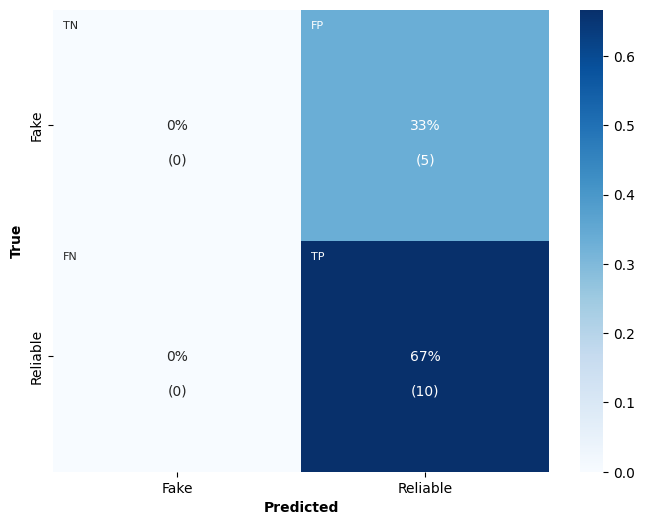

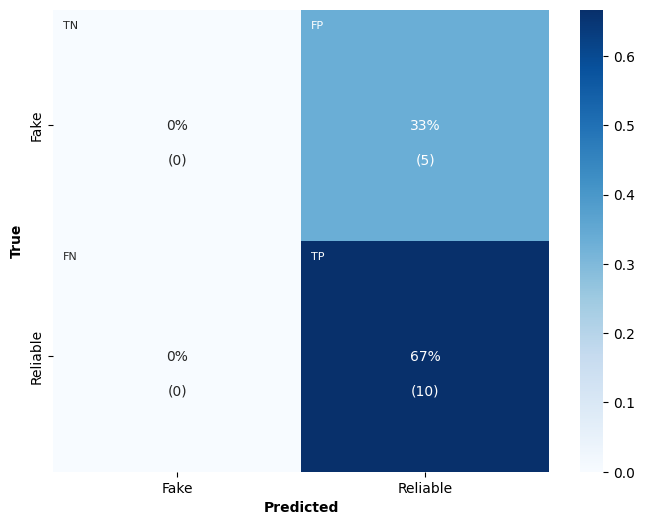

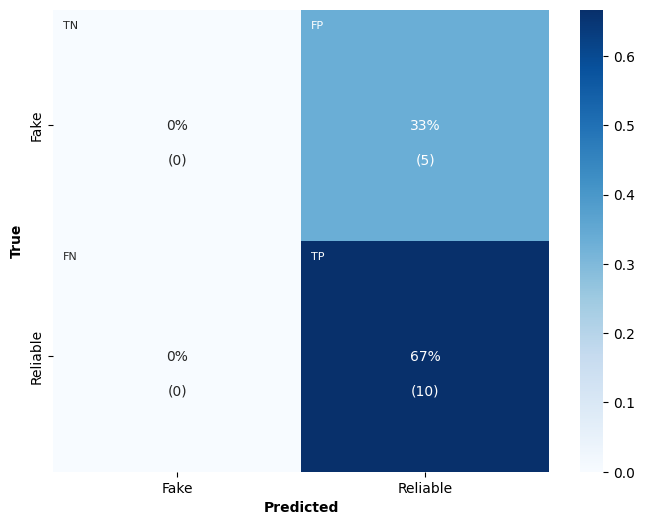

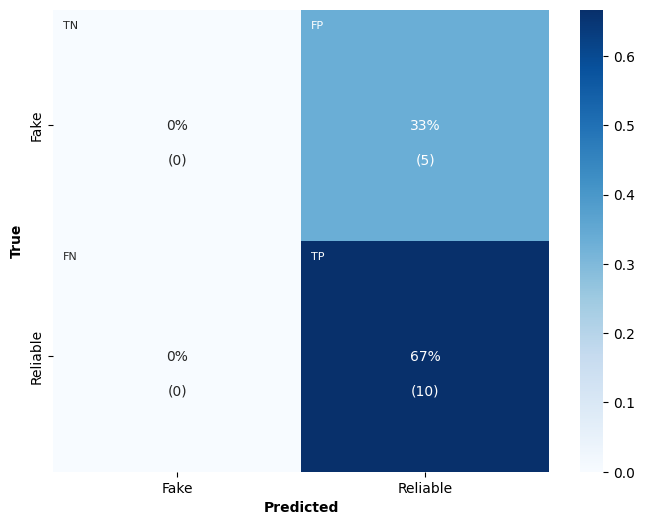

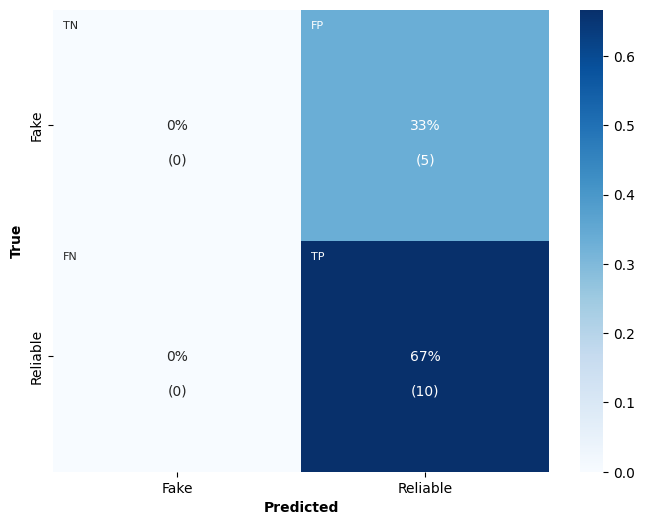

In [5]:
for metric in standard_evaluation_metrics:
    best_run = best_models_by_metrics_flattened[metric.name]
    best_model_run_id = best_run.info.run_id
    run_artifacts_path = get_best_model_artifacts_path(best_model_run_id)
    plot_confusion_matrix(run_artifacts_path,
                          metric,
                          dataset_name=dataset_name)

#### ROC Curve

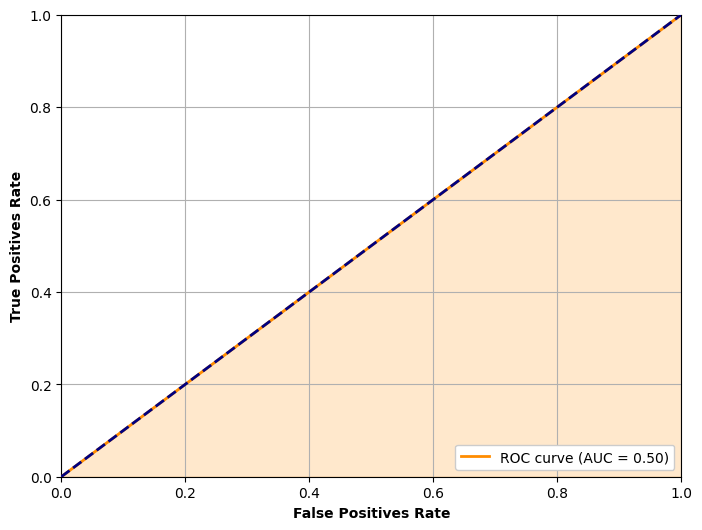

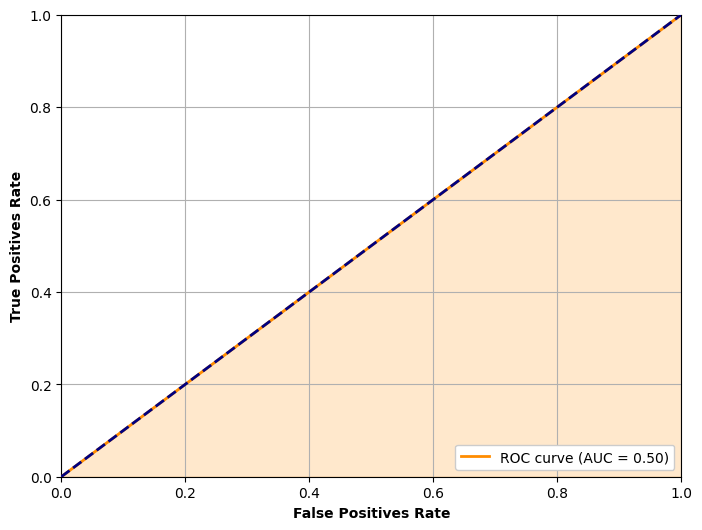

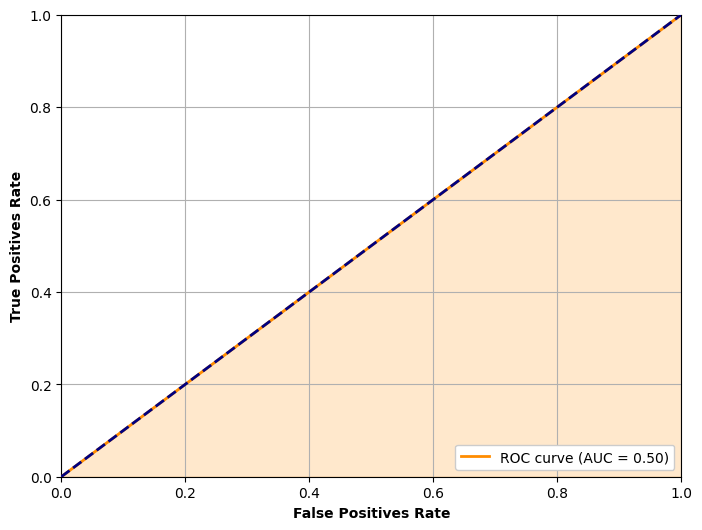

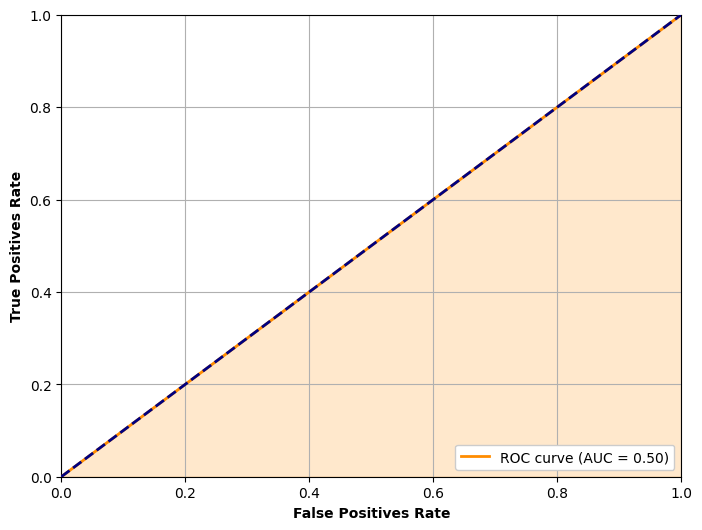

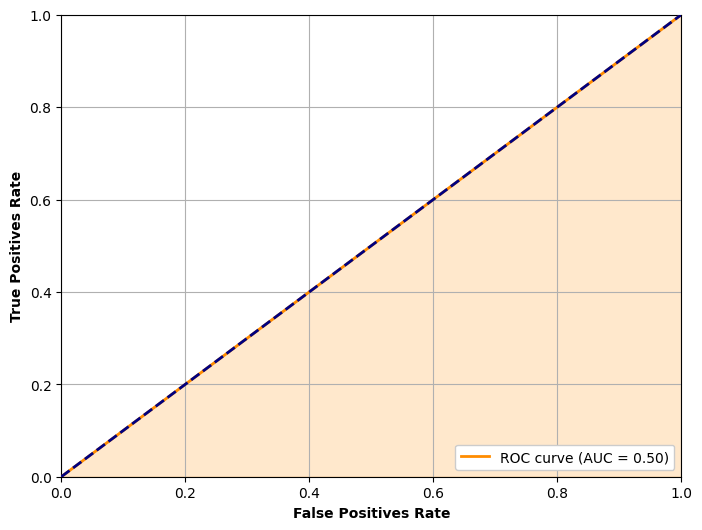

In [7]:
for metric in standard_evaluation_metrics:
    best_run = best_models_by_metrics_flattened[metric.name]
    best_model_run_id = best_run.info.run_id
    run_artifacts_path = get_best_model_artifacts_path(best_model_run_id)
    plot_roc_curve(run_artifacts_path,
                   metric,
                   dataset_name=dataset_name)

#### Metrics Table

In [33]:
import os

metrics_tables = dict()
for metric in standard_evaluation_metrics:
    metrics_dict_table = {}
    metrics_to_gather = standard_metrics + [Loss]
    for m in metrics_to_gather:
        key = f'test_{m.name}_by_{metric.name}'
        value = best_models_by_metrics_flattened[metric.name].data.metrics[key]
        label = METRICS_PLOT_NAMES_MAPPING[m.name]
        metrics_dict_table[label] = value
    metrics_tables[metric] = metrics_dict_table

for metric, metrics_data in metrics_tables.items():
    df = pd.DataFrame(list(metrics_data.items()), columns=['Metric', 'Value'])
    output_dir = f'assets/{dataset_name}/metrics/'
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, f'metrics_table_by_{metric.name}.csv')
    df.to_csv(output_path, index=False)

#### Hyperparameters Tables

##### Model Hyperparameters

In [39]:
best_models_by_metrics_flattened['precision'].data.params['model_input_hyperparameters']

"{'epochs': 10, 'batch_size': 16, 'eval_batch_size': 16, 'learning_rate': 5e-05, 'lr_scheduler': 'linear', 'weight_decay': 0.001, 'optimizer': 'adamw_torch', 'early_stopping_patience': 3, 'early_stopping_threshold': 0.01}"

##### Preprocessings Hyperparameters

In [43]:
best_models_by_metrics_flattened['precision'].data.params['model_input_hyperparameters']

"{'epochs': 10, 'batch_size': 16, 'eval_batch_size': 16, 'learning_rate': 5e-05, 'lr_scheduler': 'linear', 'weight_decay': 0.001, 'optimizer': 'adamw_torch', 'early_stopping_patience': 3, 'early_stopping_threshold': 0.01}"